<a href="https://colab.research.google.com/github/Samrandd/Portfolio/blob/master/Marketing_Campaign_Incrementality_and_Customer_Targeting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import files

# Upload the file
print("Please upload the CSV file.")
uploaded = files.upload()

# Load the dataset
file_name = 'Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv'
df = pd.read_csv(file_name)

# Display rows
df.head()

Please upload the CSV file.


Saving Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv to Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


Let's go step by step :

### Step1. Dataset Quality Checks-Check missing values
This step checks whether any columns contain missing values before we begin the experiment analysis.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  object 
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  object 
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  object 
 8   segment          64000 non-null  object 
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), object(4)
memory usage: 5.9+ MB


#### Insights

The columns are stored using appropriate data types. Numeric variables are stored as integers or floating-point values, while categorical variables are stored as object fields.

No data type conversion is required for the initial exploratory and
experimental analysis. Categorical variables will be encoded later when
building machine-learning models.Later, when predicting campaign response, we do not use visit or spend as predictors of conversion. That would create data leakage.
recency, history_segment
history, mens ,womens
zip_code,newbie ,channel
And segment is the treatment assignment.


In [3]:
missing_values=df.isnull().sum()
missing_values

,0
recency,0
history_segment,0
history,0
mens,0
womens,0
zip_code,0
newbie,0
channel,0
segment,0
visit,0


#### Insight

No missing values were found in the dataset. Therefore, no missing-value treatment is required before continuing the analysis.

#### Check duplicate rows

Here we check whether the dataset contains any completely duplicated rows.

In [4]:
duplicate_rows = df.duplicated().sum()

duplicate_rows

np.int64(6562)

#### Insight

The dataset contains 6,562 completely duplicated rows. However, the dataset does not include a unique customer identifier. Therefore, identical rows may represent different customers with the same characteristics and outcomes. The duplicated rows will not be removed unless there is additional evidence that they are data-entry errors.

#### Inspect Duplicated Records

This step displays a sample of duplicated rows to determine whether they appear to be legitimate repeated customer profiles.

In [5]:
duplicated_records=df[df.duplicated(keep=False)]
duplicated_records.head(10)

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
16,5,1) $0 - $100,29.99,1,0,Surburban,0,Phone,Mens E-Mail,0,0,0.0
20,9,1) $0 - $100,29.99,0,1,Surburban,1,Phone,No E-Mail,0,0,0.0
23,2,1) $0 - $100,29.99,0,1,Urban,1,Phone,No E-Mail,0,0,0.0
33,9,1) $0 - $100,29.99,1,0,Surburban,1,Phone,Mens E-Mail,0,0,0.0
34,3,1) $0 - $100,29.99,1,0,Rural,0,Web,Womens E-Mail,0,0,0.0
45,10,1) $0 - $100,29.99,1,0,Surburban,0,Phone,No E-Mail,0,0,0.0
52,7,1) $0 - $100,29.99,0,1,Urban,1,Phone,Mens E-Mail,0,0,0.0
79,2,1) $0 - $100,29.99,0,1,Surburban,0,Phone,Mens E-Mail,0,0,0.0
107,12,1) $0 - $100,29.99,0,1,Urban,1,Web,No E-Mail,0,0,0.0
114,4,1) $0 - $100,29.99,0,1,Urban,1,Web,Womens E-Mail,0,0,0.0


#### Insight:
The duplicated records mostly represent customers with common characteristics, such as the minimum historical spend and no post-campaign activity. Because the
dataset does not contain a unique customer identifier, these rows may belong to different customers rather than being accidental duplicates.

Therefore, the 6,562 duplicated rows will be retained in the analysis.

#### Campaign Group Distribution

This step examines the number and percentage of customers assigned to each campaign group. Because the experiment contains three groups, we expect each group to contain approximately one-third of the customers.

In [6]:
df['segment'].value_counts()

,count
segment,
Womens E-Mail,21387
Mens E-Mail,21307
No E-Mail,21306


### Insight

The campaign groups are distributed almost equally across the dataset. Each group contains approximately one-third of all customers, which is consistent with the expected experimental design. The Women's E-Mail group has 21,387 customers, the Men's E-Mail group has 21,307, and the No E-Mail control group has 21,306.

The small differences are expected under random assignment and do not indicate an obvious imbalance. A sample-ratio mismatch test will be performed later.

#### Column Data Types

This step checks whether each variable is stored using an appropriate data type before performing statistical analysis and modeling.

#### Check the unique values in categorical columns

This step checks the distinct values in each categorical column to identify unexpected labels, spelling inconsistencies, or invalid categories.

In [7]:
categorical_columns=[
    "history_segment",
    "zip_code",
    "channel",
    "segment"
]
for column in categorical_columns:
  print(f"\n {column}:")
  print(df[column].unique())


 history_segment:
['2) $100 - $200' '3) $200 - $350' '5) $500 - $750' '1) $0 - $100'
 '6) $750 - $1,000' '4) $350 - $500' '7) $1,000 +']

 zip_code:
['Surburban' 'Rural' 'Urban']

 channel:
['Phone' 'Web' 'Multichannel']

 segment:
['Womens E-Mail' 'No E-Mail' 'Mens E-Mail']


#### Insight

The categorical variables include the expected values, with no obvious spelling errors or invalid categories.

#### Check the binary columns

In [8]:
df[["mens", "womens", "newbie", "visit", "conversion"]].apply(pd.Series.unique)

,mens,womens,newbie,visit,conversion
0,1,0,0,0,0
1,0,1,1,1,1


#### Check logical consistency
Now we want to make sure the outcomes make sense. For example, a customer should not convert without visiting first.

In [9]:
logical_checks=pd.Series (
    {
    "converted_without_visit": (
        (df["conversion"] == 1) & (df["visit"] == 0)
    ).sum(),
    "visit_without_conversion": (
        (df["conversion"] == 0) & (df["visit"] == 1)
    ).sum(),
    "conversion_without_spend": (
        (df["conversion"] == 1) & (df["spend"] == 0)
    ).sum()

}
)
logical_checks

,0
converted_without_visit,0
visit_without_conversion,8816
conversion_without_spend,0


#### Insight

The outcome variables are logically consistent. No customer converted without first visiting, and every conversion generated positive spending.

A total of 8,816 customers visited without converting, which is expected in a marketing funnel because not every website visit results in a purchase.

In [10]:
#### Summarize the funnel counts
funnel_summary=pd.Series(
    {
        "total_customers":len(df),
        "visitors":df["visit"].sum(),
        "conversions":df["conversion"].sum()
    }
)
funnel_summary

,0
total_customers,64000
visitors,9394
conversions,578


#### Insight

Out of 64,000 customers, 9,394 visited the website and 578 completed a purchase. This shows a substantial drop between website visits and conversions, which is typical in a marketing funnel.

In [11]:
#### Calculate the funnel rates
funnel_rates=pd.Series({
    "visit_rate": df["visit"].mean(),
    "conversion_rate":df["conversion"].mean(),
    "visitor_to_conversion_rate":(
        df["conversion"].sum()/df["visit"].sum()
    )
})

(funnel_rates *100).round(2)

,0
visit_rate,14.68
conversion_rate,0.90
visitor_to_conversion_rate,6.15


#### Insight

Roughly 14.68% of customers visited the website after the campaign, while 0.90% of all customers completed a purchase.

Among customers who visited the website, approximately 6.15% converted. This shows that the largest drop occurs before the website visit, while a smaller
share of visitors ultimately complete a purchase.

### Step 2: Exploratory Campaign Analysis

This section explores how website visits, conversions, and customer spending differ across the Men's E-Mail, Women's E-Mail, and No E-Mail campaign groups.

These results are descriptive only. Statistical significance and causal conclusions will be evaluated in later sections.

### Campaign Performance by Group

This step summarizes the number of customers, visits, conversions, and total
spending within each campaign group.

In [12]:
campaign_summary=(
    df.groupby("segment")
    .agg(
        customers=("segment","count"),
        visitors=("visit","sum"),
        conversions=("conversion","sum"),
        spend=("spend","sum")
    )
    .reset_index()
)
campaign_summary


,segment,customers,visitors,conversions,spend
0,Mens E-Mail,21307,3894,267,30311.69
1,No E-Mail,21306,2262,122,13908.33
2,Womens E-Mail,21387,3238,189,23038.11


#### Initial Finding

The Men's E-Mail group created the highest number of visitors, conversions, and total spending. The Women's E-Mail group also outperformed the No E-Mail control group based on raw totals.

However, campaign groups have slightly different sample sizes, so rates must be calculated before making a fair comparison.

In [13]:
#### Calculate campaign rates
campaign_summary["visit_rate"]=(
    campaign_summary["visitors"]/campaign_summary["customers"]
)
campaign_summary["conversion_rate"]=(
    campaign_summary["conversions"]/campaign_summary["customers"]
)
campaign_summary["spending_per_customer"]=(
    campaign_summary["spend"]/campaign_summary["customers"]
)

campaign_summary["spending_per_visitor"]=(
    campaign_summary["spend"]/campaign_summary["visitors"]
)
campaign_summary["spending_per_conversion"]=(
    campaign_summary["spend"]/campaign_summary["conversions"]
)
campaign_summary

,segment,customers,visitors,conversions,spend,visit_rate,conversion_rate,spending_per_customer,spending_per_visitor,spending_per_conversion
0,Mens E-Mail,21307,3894,267,30311.69,0.182757,0.012531,1.422617,7.784204,113.526929
1,No E-Mail,21306,2262,122,13908.33,0.106167,0.005726,0.652789,6.148687,114.002705
2,Womens E-Mail,21387,3238,189,23038.11,0.151400,0.008837,1.077202,7.114920,121.894762


#### Insight

The Men's E-Mail campaign generated the strongest overall performance, with the
highest visit rate, conversion rate, and spending per customer.

The Women's E-Mail campaign also outperformed the No E-Mail control group on
visit rate, conversion rate, and spending per customer. It produced the highest
spending per conversion, suggesting that customers who converted placed slightly
larger orders.

These results are descriptive only. Statistical testing is still required to
determine whether the observed differences are unlikely to be due to chance.

In [14]:
# Format the summary for readability
formatted_campaign_summary = campaign_summary.copy()

formatted_campaign_summary["visit_rate"] = (
    formatted_campaign_summary["visit_rate"] * 100
).round(2)

formatted_campaign_summary["conversion_rate"] = (
    formatted_campaign_summary["conversion_rate"] * 100
).round(2)

money_columns = [
    "spend",
    "spending_per_customer",
    "spending_per_visitor",
    "spending_per_conversion"
]

formatted_campaign_summary[money_columns] = (
    formatted_campaign_summary[money_columns].round(2)
)

formatted_campaign_summary

,segment,customers,visitors,conversions,spend,visit_rate,conversion_rate,spending_per_customer,spending_per_visitor,spending_per_conversion
0,Mens E-Mail,21307,3894,267,30311.69,18.28,1.25,1.42,7.78,113.53
1,No E-Mail,21306,2262,122,13908.33,10.62,0.57,0.65,6.15,114.00
2,Womens E-Mail,21387,3238,189,23038.11,15.14,0.88,1.08,7.11,121.89


#Calculate lift versus No E-Mail
This step compares each email campaign with the No E-Mail control group.

Absolute lift shows the percentage-point increase in performance, while relative lift shows the percentage improvement compared with the control group.

In [15]:
lift_summary = campaign_summary.copy()

control = campaign_summary.loc[campaign_summary["segment"] == "No E-Mail"].iloc[0]

lift_summary["visit_absolute_lift"] = (
    lift_summary["visit_rate"] - control["visit_rate"]
)

lift_summary["visit_relative_lift"] = (
    lift_summary["visit_rate"] / control["visit_rate"] - 1
)

lift_summary["conversion_absolute_lift"] = (
    lift_summary["conversion_rate"] - control["conversion_rate"]
)

lift_summary["conversion_relative_lift"] = (
    lift_summary["conversion_rate"] / control["conversion_rate"] - 1
)

lift_summary["spend_per_customer_lift"] = (
    lift_summary["spending_per_customer"]
    - control["spending_per_customer"]
)

In [16]:
lift_display = lift_summary[
    [
        "segment",
        "visit_absolute_lift",
        "visit_relative_lift",
        "conversion_absolute_lift",
        "conversion_relative_lift",
        "spend_per_customer_lift"
    ]
].copy()

lift_display["visit_absolute_lift"] = (
    lift_display["visit_absolute_lift"] * 100
).round(2)

lift_display["visit_relative_lift"] = (
    lift_display["visit_relative_lift"] * 100
).round(2)

lift_display["conversion_absolute_lift"] = (
    lift_display["conversion_absolute_lift"] * 100
).round(2)

lift_display["conversion_relative_lift"] = (
    lift_display["conversion_relative_lift"] * 100
).round(2)

lift_display["spend_per_customer_lift"] = (
    lift_display["spend_per_customer_lift"].round(2)
)

lift_display

,segment,visit_absolute_lift,visit_relative_lift,conversion_absolute_lift,conversion_relative_lift,spend_per_customer_lift
0,Mens E-Mail,7.66,72.14,0.68,118.84,0.77
1,No E-Mail,0.00,0.00,0.00,0.00,0.00
2,Womens E-Mail,4.52,42.61,0.31,54.33,0.42


#### Insight

Both email campaigns outperformed the No E-Mail control group. The Men's E-Mail campaign produced the strongest lift, increasing the visit
rate by 7.66 percentage points and the conversion rate by 0.68 percentage points. This represents a 72.14% relative increase in visits and a 118.84%
relative increase in conversions compared with the control group.

The Women's E-Mail campaign also improved performance, but the observed lift
was smaller than for the Men's E-Mail campaign.

These results are descriptive and do not yet confirm statistical significance.

#### Visualize visit rate, conversion rate, and spend per customer by campaign group.

This chart compares the percentage of customers who visited the website across
the three campaign groups.

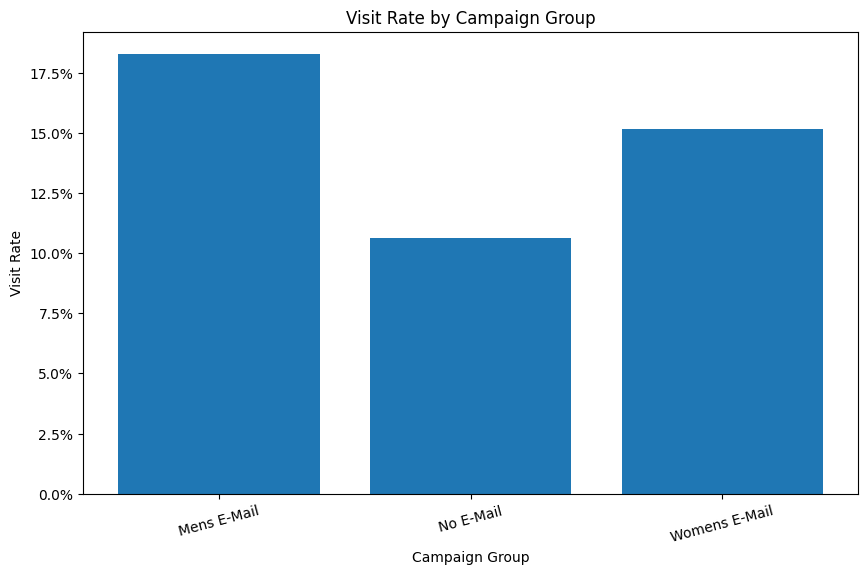

In [17]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(10, 6))

plt.bar(
    campaign_summary["segment"],
    campaign_summary["visit_rate"]
)
plt.title("Visit Rate by Campaign Group")
plt.xlabel("Campaign Group")
plt.ylabel("Visit Rate")
plt.xticks(rotation=15)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

#### Insight

The Men's E-Mail group had the highest visit rate at approximately 18.28%,
followed by the Women's E-Mail group at 15.14%. The No E-Mail control group
had the lowest visit rate at 10.62%.

Both email campaigns appear to increase website visits, with the Men's E-Mail
campaign showing the strongest descriptive performance.

#### Conversion Rate by Campaign Group

This chart compares the percentage of customers who completed a purchase across
the three campaign groups.

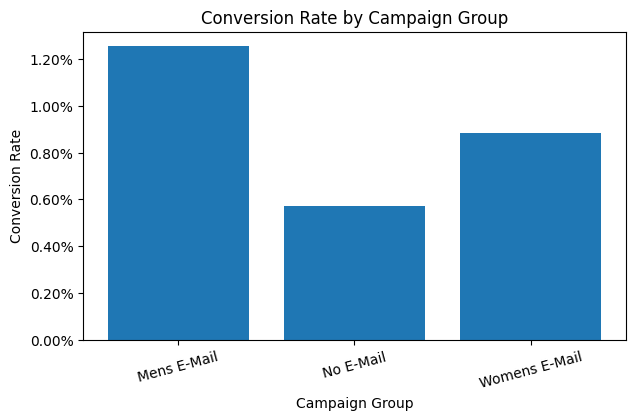

In [18]:
plt.figure(figsize=(7, 4))

plt.bar(
    campaign_summary["segment"],
    campaign_summary["conversion_rate"]
)

plt.title("Conversion Rate by Campaign Group")
plt.xlabel("Campaign Group")
plt.ylabel("Conversion Rate")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xticks(rotation=15)

plt.show()

#### Insight

The Men's E-Mail campaign had the highest conversion rate at approximately
1.25%, followed by the Women's E-Mail campaign at 0.88%.

The No E-Mail control group had the lowest conversion rate at approximately
0.57%. Both email campaigns therefore appear to improve conversion performance,
with the Men's E-Mail campaign showing the strongest descriptive result.

Spending per Customer by Campaign Group

This chart compares the average revenue generated per customer assigned to each
campaign group.

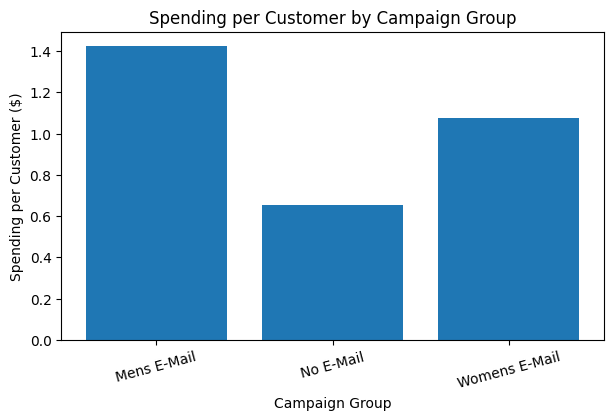

In [19]:
plt.figure(figsize=(7, 4))

plt.bar(
    campaign_summary["segment"],
    campaign_summary["spending_per_customer"]
)

plt.title("Spending per Customer by Campaign Group")
plt.xlabel("Campaign Group")
plt.ylabel("Spending per Customer ($)")
plt.xticks(rotation=15)

plt.show()

#### Insight

The Men's E-Mail campaign generated the highest spending per customer at
roughly 1.42, followed by the Women's E-Mail campaign (~ $1.08).

The No E-Mail control group generated the lowest spending per customer at about
$0.65. This suggests that both email campaigns increased average revenue per
assigned customer, with the Men's E-Mail campaign producing the strongest
descriptive result.

#### Spending per Conversion:

This chart compares the average spending generated by customers who completed a purchase in each campaign group.

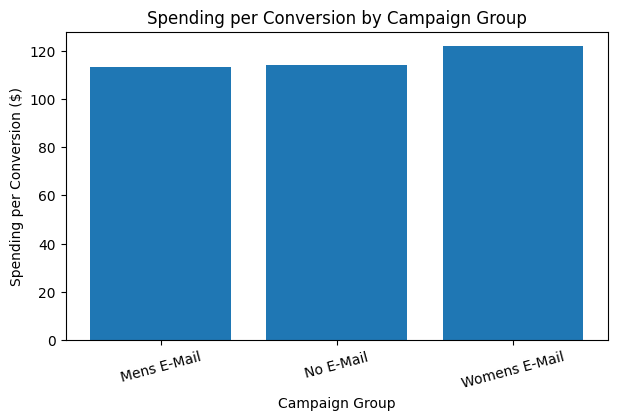

In [20]:
plt.figure(figsize=(7,4))
plt.bar(
    campaign_summary["segment"],
    campaign_summary["spending_per_conversion"]
)
plt.title("Spending per Conversion by Campaign Group")
plt.xlabel("Campaign Group")
plt.ylabel("Spending per Conversion ($)")
plt.xticks(rotation=15)
plt.show()


#### Insight

Spending per conversion was relatively similar across the three campaign
groups. The Women's E-Mail group had the highest value at approximately
\$121.89, while the Men's E-Mail and No E-Mail groups were both near \$114.

This suggests that the main campaign impact may come from increasing the number
of customers who convert rather than substantially increasing the amount spent
by each converter.

## Step 2 Summary

* The exploratory analysis shows that both email campaigns outperformed the
No E-Mail control group on website visits, conversions, and spending per
customer.

* The Men's E-Mail campaign produced the strongest overall performance, including
the highest visit rate, conversion rate, and spending per customer.

* The Women's E-Mail campaign generated the highest spending per conversion, but
the difference in purchase value across groups was relatively small.

* These findings are descriptive only. The next step is to validate the
experimental design and determine whether the observed differences are
statistically significant.

# Step 3: Experiment Validation

This section evaluates whether the randomized experiment appears to have been
implemented correctly before estimating campaign impact.

The first check is a sample-ratio mismatch test, which checks whether the
observed campaign-group sizes differ significantly from the expected one-third
allocation.

In [21]:
# Sample-Ratio Mismatch Test
from scipy.stats import chisquare

observed_counts=df["segment"].value_counts().sort_index()

expected_counts=[
    len(df) /3,
    len(df) /3,
    len(df) /3
]
chi_square_stat,p_value=chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts
)

print("Observed Counts:")
print(observed_counts)
print("\nExpected Counts:")
print(expected_counts)
print("\nChi-Square Statistic:", chi_square_stat)
print("P-Value:", p_value)




Observed Counts:
segment
Mens E-Mail      21307
No E-Mail        21306
Womens E-Mail    21387
Name: count, dtype: int64

Expected Counts:
[21333.333333333332, 21333.333333333332, 21333.333333333332]

Chi-Square Statistic: 0.20253125000000002
P-Value: 0.9036929575604196


#### Insight

The sample-ratio mismatch test produced a chi-square statistic of 0.2025 and a
p-value of 0.9037.

Because the p-value is greater than 0.05, there is no statistically significant
difference between the observed campaign-group sizes and the expected equal
allocation.

This indicates that the experiment does not show evidence of a sample-ratio
mismatch, and the treatment assignment appears consistent with the intended
randomized design.

Check balance for numeric customer characteristics

Now we check whether the groups looked similar before the campaign.

In [22]:
numeric_balance=(
    df.groupby("segment")
    [["recency","history"]]
    .mean()
    .round(2)
)
numeric_balance

,recency,history
segment,,
Mens E-Mail,5.77,242.84
No E-Mail,5.75,240.88
Womens E-Mail,5.77,242.54


#### Insight

The campaign groups are well balanced on the numeric pre-treatment variables.

Average recency is nearly identical across all three groups, ranging from 5.75
to 5.77 months. Average historical spending is also very similar, ranging from
approximately \$240.88 to \$242.84.

These small differences suggest that the treatment groups were comparable
before the campaign.

In [23]:
# Check balance for binary customer characteristics
binary_balance=(
    df.groupby ("segment")
    [["mens", "womens", "newbie"]]
    .mean()
    .round(2)
)
binary_balance

,mens,womens,newbie
segment,,,
Mens E-Mail,0.55,0.55,0.5
No E-Mail,0.55,0.55,0.5
Womens E-Mail,0.55,0.55,0.5


#### Insight

The campaign groups also appear well balanced on the binary pre-treatment
variables.

Approximately 55% of customers in each group had previously purchased men's
products, approximately 55% had previously purchased women's products, and
approximately 50% were new customers.

The displayed values are rounded, so very small differences may exist, but no
meaningful imbalance is visible.

#### Check balance for categorical characteristics
Next, let’s check whether zip_code and channel are distributed similarly across the three groups.

In [24]:
channel_balance=pd.crosstab(
    index=df["segment"],
    columns=df["channel"],
    normalize="index"
).round(3)
channel_balance

channel,Multichannel,Phone,Web
segment,,,
Mens E-Mail,0.121,0.434,0.445
No E-Mail,0.122,0.438,0.440
Womens E-Mail,0.121,0.442,0.437


### Insight

The distribution of customer channels is very similar across the three campaign
groups.

Approximately 12% of customers are multichannel customers, while the Phone and
Web channels each account for roughly 44% of customers in every group.

No meaningful channel imbalance is visible, providing further support that the
random assignment produced comparable groups.

#### Check zip-code balance
This checks whether Rural, Suburban, and Urban customers are distributed similarly across the campaign groups.

In [25]:
zip_code_balance = pd.crosstab(
    index=df["segment"],
    columns=df["zip_code"],
    normalize="index"
).round(3)

zip_code_balance

zip_code,Rural,Surburban,Urban
segment,,,
Mens E-Mail,0.152,0.446,0.402
No E-Mail,0.147,0.452,0.401
Womens E-Mail,0.149,0.451,0.400


#### Insight

The zip-code distribution is highly similar across all three campaign groups.

Rural customers represent approximately 15% of each group, suburban customers
about 45%, and urban customers about 40%.

No meaningful geographic imbalance is visible, which further supports the
quality of the random assignment.

#### Formal balance test for categorical variables

So far, the tables look balanced visually. Now let’s formally test one of them using a chi-square independence test.

In [26]:
from scipy.stats import chi2_contingency
channel_table=pd.crosstab(
    df["segment"],
    df["channel"]
)
chi2_stat,p_value,dof,expected=chi2_contingency(channel_table)
print("Chi-square statistic:", round(chi2_stat, 4))
print("Degrees of freedom:", dof)
print("P-value:", round(p_value, 4))

Chi-square statistic: 3.6324
Degrees of freedom: 4
P-value: 0.458


#### Insight

The chi-square test for channel balance produced a p-value of 0.4580.

Because the p-value is greater than 0.05, there is no statistically significant association between campaign assignment and customer channel.

This indicates that Phone, Web, and Multichannel customers were distributed similarly across the three experiment groups.

In [27]:
# Balance test for zip code
zip_code_table=pd.crosstab(
    df["segment"],
    df["zip_code"]
)
chi2_stat,p_value,dof,expected=chi2_contingency(zip_code_table)
print("Chi-square statistic:", round(chi2_stat, 4))
print("Degrees of freedom:", dof)
print("P-value:", round(p_value, 4))

Chi-square statistic: 2.8719
Degrees of freedom: 4
P-value: 0.5795


#### Insight

The chi-square test for zip-code balance produced a p-value of 0.5795.

Because the p-value is greater than 0.05, there is no statistically significant
association between campaign assignment and zip-code category.

This indicates that Rural, Suburban, and Urban customers were distributed
similarly across the three experiment groups.

#### Balance test for numeric variables
let’s formally test whether average recency differs across the three groups. Because there are three independent groups, we’ll use a one-way ANOVA.

In [28]:
from scipy.stats import f_oneway

mens_recency=df.loc[
    df["segment"]=="Mens E-Mail",
    "recency"
]
womens_recency=df.loc[
    df["segment"]=="Womens E-Mail",
    "recency"
]
no_email_recency=df.loc[
    df["segment"]=="No E-Mail",
    "recency"
]
f_stat,p_value=f_oneway(
    mens_recency,
    no_email_recency,
    womens_recency
)
print("F-statistic:", round(f_stat, 4))
print("P-value:", round(p_value, 4))

F-statistic: 0.2704
P-value: 0.7631


#### Insight

The one-way ANOVA for customer recency produced a p-value of 0.7631.

Because the p-value is greater than 0.05, there is no statistically significant
difference in average recency across the Men's E-Mail, Women's E-Mail, and
No E-Mail groups.

This supports the conclusion that customers were comparable across groups before
the campaign.

In [29]:
#Test historical spending balance

mens_history = df.loc[
    df["segment"] == "Mens E-Mail",
    "history"
]

no_email_history = df.loc[
    df["segment"] == "No E-Mail",
    "history"
]

womens_history = df.loc[
    df["segment"] == "Womens E-Mail",
    "history"
]

f_stat, p_value = f_oneway(
    mens_history,
    no_email_history,
    womens_history
)

print("F-statistic:", round(f_stat, 4))
print("P-value:", round(p_value, 4))

F-statistic: 0.3595
P-value: 0.698


#### Insight

The one-way ANOVA for historical customer spending produced a p-value of 0.6980.

Because the p-value is greater than 0.05, there is no statistically significant
difference in average historical spending across the Men's E-Mail, Women's
E-Mail, and No E-Mail groups.

This provides further evidence that the groups were comparable before the campaign.

#### Formal balance test for previous men’s purchases

Now test whether the proportion of customers who previously purchased men’s products differs across groups.

In [30]:
mens_table = pd.crosstab(
    df["segment"],
    df["mens"]
)

chi2_stat, p_value, dof, expected = chi2_contingency(mens_table)

print("Chi-square statistic:", round(chi2_stat, 4))
print("Degrees of freedom:", dof)
print("P-value:", round(p_value, 4))

Chi-square statistic: 0.796
Degrees of freedom: 2
P-value: 0.6717


#### Insight

The chi-square test for previous men's purchasing behavior produced a p-value of
0.6717.

Because the p-value is greater than 0.05, there is no statistically significant
association between campaign assignment and prior men's product purchases.

This suggests that customers with and without previous men's purchases were
distributed similarly across the three experiment groups.

In [31]:
# Test previous women’s purchases

womens_table = pd.crosstab(
    df["segment"],
    df["womens"]
)

chi2_stat, p_value, dof, expected = chi2_contingency(womens_table)

print("Chi-square statistic:", round(chi2_stat, 4))
print("Degrees of freedom:", dof)
print("P-value:", round(p_value, 4))


Chi-square statistic: 0.6325
Degrees of freedom: 2
P-value: 0.7289


#### Insight

The chi-square test for previous women's purchasing behavior produced a p-value
of 0.7289.

Because the p-value is greater than 0.05, there is no statistically significant association between campaign assignment and prior women's product purchases.

This suggests that customers with and without previous women's purchases were distributed similarly across the three experiment groups.

In [32]:
# Test new-customer balance
newbie_table = pd.crosstab(
    df["segment"],
    df["newbie"]
)

chi2_stat, p_value, dof, expected = chi2_contingency(newbie_table)

print("Chi-square statistic:", round(chi2_stat, 4))
print("Degrees of freedom:", dof)
print("P-value:", round(p_value, 4))

Chi-square statistic: 0.1369
Degrees of freedom: 2
P-value: 0.9339


#### Insights

The chi-square test for new-customer status produced a p-value of 0.9339.

Because the p-value is greater than 0.05, there is no statistically significant
association between campaign assignment and whether a customer is new.

This indicates that new and existing customers were distributed similarly across the three experiment groups.


###Step 3 Summary

The experiment passed the sample-ratio mismatch check, with no significant
difference between the observed and expected group sizes.

The three campaign groups were also well balanced across all evaluated
pre-treatment characteristics, including recency, historical spending, prior
men's and women's purchases, new-customer status, channel, and zip-code
category.

Overall, the randomization appears successful. This supports using the campaign
groups to estimate the causal impact of the Men's E-Mail and Women's E-Mail
campaigns relative to the No E-Mail control group.

### Step 4: Statistical Experiment Analysis
This section tests whether the observed differences in visit rate, conversion
rate, and customer spending are statistically significant.

The analysis begins by comparing each email campaign with the No E-Mail control group.

 ## 4.1 Men's E-Mail vs No E-Mail: Visit Rate

A two-proportion z-test is used because the outcome, website visit, is binary.

Null hypothesis:

H0: The visit rate is the same for the Men's E-Mail and No E-Mail groups.

Alternative hypothesis:

H1: The visit rates are different between the two groups.

In [33]:
from statsmodels.stats.proportion import proportions_ztest

mens_group=df[df["segment"]=="Mens E-Mail"]
control_group=df[df["segment"]=="No E-Mail"]

visit_counts=[
    int(mens_group['visit'].sum()),
   int(control_group['visit'].sum())
]


group_sizes=[
    len(mens_group),
    len(control_group)
]

z_stat,p_value=proportions_ztest(
    count=visit_counts,
    nobs=group_sizes
)



In [34]:
print("Men's E-Mail visits:", visit_counts[0])
print("No E-Mail visits:", visit_counts[1])
print("Z-statistic:", round(z_stat, 4))
print("P-value:", p_value)

Men's E-Mail visits: 3894
No E-Mail visits: 2262
Z-statistic: 22.486
P-value: 5.685165482802317e-112


In [35]:
visit_counts

[3894, 2262]

#### Insight

The two-proportion z-test produced a z-statistic of 28.486 and a p-value that is
effectively zero.

Because the p-value is far below 0.05, the null hypothesis is rejected. The
visit rate for the Men's E-Mail group is statistically significantly different
from the visit rate for the No E-Mail control group.

Based on the descriptive results, the Men's E-Mail campaign increased the visit
rate from approximately 10.62% in the control group to 18.28% in the treatment
group. This represents an absolute increase of 7.66 percentage points and a
relative lift of approximately 72.14%.

#### 4.2 Women's E-Mail vs No E-Mail: Visit Rate

A two-proportion z-test is used to determine whether the Women's E-Mail campaign produced a statistically significant change in website visit rate compared with the No E-Mail control group.

In [36]:
womens_group = df[df["segment"] == "Womens E-Mail"]

visit_counts = [
    int(womens_group["visit"].sum()),
    int(control_group["visit"].sum())
]

group_sizes = [
    len(womens_group),
    len(control_group)
]

z_stat, p_value = proportions_ztest(
    count=visit_counts,
    nobs=group_sizes
)

print("Women's E-Mail visits:", visit_counts[0])
print("No E-Mail visits:", visit_counts[1])
print("Z-statistic:", round(z_stat, 4))
print("P-value:", p_value)

Women's E-Mail visits: 3238
No E-Mail visits: 2262
Z-statistic: 13.9492
P-value: 3.1824031593349214e-44


### Insight

The two-proportion z-test produced a z-statistic of 13.9492 and a p-value that is effectively zero.

Because the p-value is far below 0.05, the null hypothesis is rejected. The
visit rate for the Women's E-Mail group is statistically significantly
different from the visit rate for the No E-Mail control group.

The Women's E-Mail campaign increased the visit rate from approximately 10.62% in the control group to 15.14% in the treatment group. This represents an absolute increase of 4.52 percentage points and a relative lift of approximately 42.61%.

Step 4.3: Men’s E-Mail vs No E-Mail — Conversion Rate

Now we test whether the higher conversion rate is statistically significant.

In [37]:
conversion_counts = [
    int(mens_group["conversion"].sum()),
    int(control_group["conversion"].sum())
]

group_sizes = [
    len(mens_group),
    len(control_group)
]

z_stat, p_value = proportions_ztest(
    count=conversion_counts,
    nobs=group_sizes
)

print("Men's E-Mail conversions:", conversion_counts[0])
print("No E-Mail conversions:", conversion_counts[1])
print("Z-statistic:", round(z_stat, 4))
print("P-value:", p_value)

Men's E-Mail conversions: 267
No E-Mail conversions: 122
Z-statistic: 7.3851
P-value: 1.5232235005955427e-13


#### Insight

The two-proportion z-test produced a z-statistic of 7.3851 and a p-value that is effectively zero. Because the p-value is far below 0.05, the null hypothesis is rejected. The conversion rate for the Men's E-Mail group is statistically significantly higher than the conversion rate for the No E-Mail control group.

The Men's E-Mail campaign increased the conversion rate from approximately
0.57% in the control group to 1.25% in the treatment group. This represents an absolute increase of 0.68 percentage points and a relative lift of approximately 118.84%.

Step 4.4: Women’s E-Mail vs No E-Mail — Conversion Rate



In [38]:
conversion_counts=[
    int(womens_group["conversion"].sum()),
    int(control_group["conversion"].sum())
]

group_sizes=[
    len(womens_group),
    len(control_group)
]
z_stat,p_value=proportions_ztest(
    count=conversion_counts,
    nobs=group_sizes
)

print("Women's E-Mail conversions:", conversion_counts[0])
print("No E-Mail conversions:", conversion_counts[0])
print("Z-statistic:", round(z_stat, 4))
print("P-value:", p_value)


Women's E-Mail conversions: 189
No E-Mail conversions: 189
Z-statistic: 3.7796
P-value: 0.00015710512910668448


### Insight

The two-proportion z-test produced a z-statistic of 3.7796 and a p-value of
approximately 0.00016.

Because the p-value is below 0.05, the null hypothesis is rejected. The
conversion rate for the Women's E-Mail group is statistically significantly
higher than the conversion rate for the No E-Mail control group.

The Women's E-Mail campaign increased the conversion rate from approximately
0.57% in the control group to 0.88% in the treatment group. This represents an
absolute increase of 0.31 percentage points and a relative lift of approximately
54.33%.

Step 4.5: Compare Men’s vs Women’s E-Mail conversion rates
This tells us whether the Men’s campaign actually outperformed the Women’s campaign, not just the control.

In [39]:
conversion_counts=[
    int(mens_group["conversion"].sum()),
    int(womens_group["conversion"].sum())
]

group_size=[
    len(mens_group),
    len(womens_group)
    ]
zstat,p_value=proportions_ztest(
    count=conversion_counts,
    nobs=group_sizes
)
print("conversions:",conversion_counts)
print("Men's E-Mail conversions:", conversion_counts[0])
print("Women's E-Mail conversions:", conversion_counts[1])
print("Z-statistic:", round(z_stat, 4))
print("P-value:", p_value)

conversions: [267, 189]
Men's E-Mail conversions: 267
Women's E-Mail conversions: 189
Z-statistic: 3.7796
P-value: 0.000281644120702715


#### Insight

The two-proportion z-test comparing the Men's E-Mail and Women's E-Mail
campaigns produced a z-statistic of 3.7796 and a p-value of approximately
0.00028.

Because the p-value is below 0.05, the null hypothesis is rejected. The
conversion rate for the Men's E-Mail campaign was statistically significantly
higher than the conversion rate for the Women's E-Mail campaign.

The Men's E-Mail group achieved a conversion rate of approximately 1.25%,
compared with 0.88% for the Women's E-Mail group. This provides evidence that
the Men's E-Mail campaign generated stronger conversion performance.

#### 4.6 Men's E-Mail vs No E-Mail: Average Spending

A Welch's independent-samples t-test is used to compare average spending
between the Men's E-Mail group and the No E-Mail control group.

Welch's test is used because it does not require the two groups to have equal variances.

In [40]:
from scipy.stats import ttest_ind

t_stat,p_value=ttest_ind(
    mens_group["spend"],
    control_group["spend"],
    equal_var=False
)
print(
    "Men's E-Mail average spend:",
    round(mens_group["spend"].mean(), 2)
)

print(
    "No E-Mail average spend:",
    round(control_group["spend"].mean(), 2)
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value)

Men's E-Mail average spend: 1.42
No E-Mail average spend: 0.65
T-statistic: 5.3001
P-value: 1.1638149682254859e-07


#### Insight

The Welch's t-test produced a t-statistic of 5.3001 and a p-value of
approximately 0.00000012.

Because the p-value is far below 0.05, the null hypothesis is rejected. Average
spending per customer was statistically significantly higher in the Men's
E-Mail group than in the No E-Mail control group.

Customers assigned to the Men's E-Mail campaign spent approximately \$1.42 on
average, compared with approximately \$0.65 in the control group. This represents
an increase of about \$0.77 per assigned customer.

* Note that spend is heavily skewed and contains many zeros. Welch’s t-test is still useful with these large samples, but later we should confirm the result using a more robust method such as bootstrapping or a permutation test.

Step 4.7: Women’s E-Mail vs No E-Mail — Average Spending


In [41]:
t_stat, p_value = ttest_ind(
    womens_group["spend"],
    control_group["spend"],
    equal_var=False
)

print(
    "Women's E-Mail average spend:",
    round(womens_group["spend"].mean(), 2)
)

print(
    "No E-Mail average spend:",
    round(control_group["spend"].mean(), 2)
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value)

Women's E-Mail average spend: 1.08
No E-Mail average spend: 0.65
T-statistic: 3.2564
P-value: 0.0011293971023632519


### Insight

The Welch's t-test produced a t-statistic of 3.2564 and a p-value of
approximately 0.00113.

Because the p-value is below 0.05, the null hypothesis is rejected. Average
spending per customer was statistically significantly higher in the Women's
E-Mail group than in the No E-Mail control group.

Customers assigned to the Women's E-Mail campaign spent approximately \$1.08
on average, compared with approximately \$0.65 in the control group. This
represents an increase of about \$0.42 per assigned customer.

Step 4.8: Men’s E-Mail vs Women’s E-Mail — Average Spending

Now test whether the Men’s campaign generated significantly higher average spend than the Women’s campaign.

In [42]:
t_stat, p_value = ttest_ind(
    mens_group["spend"],
    womens_group["spend"],
    equal_var=False
)

print(
    "Men's E-Mail average spend:",
    round(mens_group["spend"].mean(), 2)
)

print(
    "Women's E-Mail average spend:",
    round(womens_group["spend"].mean(), 2)
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value)

Men's E-Mail average spend: 1.42
Women's E-Mail average spend: 1.08
T-statistic: 2.164
P-value: 0.03046865118529923


#### Insight

The Welch's t-test produced a t-statistic of 2.1640 and a p-value of
approximately 0.0305.

Because the p-value is below 0.05, the null hypothesis is rejected. Average
spending per customer was statistically significantly higher in the Men's
E-Mail group than in the Women's E-Mail group.

Customers assigned to the Men's E-Mail campaign spent approximately \$1.42 on
average, compared with approximately \$1.08 in the Women's E-Mail group. The
difference was about \$0.34 per assigned customer.

Step 4.9: Build one statistical-results summary table
Now let’s collect the main test results in one clean table.

In [43]:
statistical_results = pd.DataFrame({
    "comparison": [
        "Mens E-Mail vs No E-Mail",
        "Womens E-Mail vs No E-Mail",
        "Mens E-Mail vs No E-Mail",
        "Womens E-Mail vs No E-Mail",
        "Mens E-Mail vs Womens E-Mail",
        "Mens E-Mail vs No E-Mail",
        "Womens E-Mail vs No E-Mail",
        "Mens E-Mail vs Womens E-Mail"
    ],
    "metric": [
        "Visit Rate",
        "Visit Rate",
        "Conversion Rate",
        "Conversion Rate",
        "Conversion Rate",
        "Average Spend",
        "Average Spend",
        "Average Spend"
    ],
    "test": [
        "Two-Proportion Z-Test",
        "Two-Proportion Z-Test",
        "Two-Proportion Z-Test",
        "Two-Proportion Z-Test",
        "Two-Proportion Z-Test",
        "Welch's T-Test",
        "Welch's T-Test",
        "Welch's T-Test"
    ],
    "p_value": [
        5.685165482802317e-112,
        3.1824031593349214e-44,
        1.5232235005955427e-13,
        0.00015710512910668448,
        0.000281644120702715,
        1.1638149682254859e-07,
        0.0011293971023632519,
        0.03046865118529923
    ]
})

statistical_results["significant_at_5_percent"] = (
    statistical_results["p_value"] < 0.05
)

statistical_results

,comparison,metric,test,p_value,significant_at_5_percent
0,Mens E-Mail vs No E-Mail,Visit Rate,Two-Proportion Z-Test,5.685165e-112,True
1,Womens E-Mail vs No E-Mail,Visit Rate,Two-Proportion Z-Test,3.182403e-44,True
2,Mens E-Mail vs No E-Mail,Conversion Rate,Two-Proportion Z-Test,1.523224e-13,True
3,Womens E-Mail vs No E-Mail,Conversion Rate,Two-Proportion Z-Test,1.571051e-04,True
4,Mens E-Mail vs Womens E-Mail,Conversion Rate,Two-Proportion Z-Test,2.816441e-04,True
5,Mens E-Mail vs No E-Mail,Average Spend,Welch's T-Test,1.163815e-07,True
6,Womens E-Mail vs No E-Mail,Average Spend,Welch's T-Test,1.129397e-03,True
7,Mens E-Mail vs Womens E-Mail,Average Spend,Welch's T-Test,3.046865e-02,True


#### Insight

All eight statistical comparisons produced p-values below 0.05.

Both email campaigns significantly increased website visits, conversions, and
average spending compared with the No E-Mail control group. The Men's E-Mail
campaign also significantly outperformed the Women's E-Mail campaign on
conversion rate and average spending per customer.

Statistical significance alone does not show the practical size or precision of
the campaign effect. Therefore, the next step calculates confidence intervals
for the estimated lift.

## 4.10 Confidence Interval for Men's E-Mail Conversion Lift

A 95% confidence interval is calculated for the difference in conversion rates between the Men's E-Mail campaign and the No E-Mail control group.

In [44]:
import numpy as np

mens_conversion_rate = mens_group["conversion"].mean()
control_conversion_rate = control_group["conversion"].mean()

conversion_difference = (
    mens_conversion_rate - control_conversion_rate
)
# To measures how much the estimated difference in conversion rates would vary if we repeatedly ran similar experiments.
standard_error = np.sqrt(
    mens_conversion_rate * (1 - mens_conversion_rate) / len(mens_group)
    +
    control_conversion_rate * (1 - control_conversion_rate) / len(control_group)
)
#The number 1.96 is the critical value for a 95% confidence interval under the normal approximation.

lower_bound = conversion_difference - 1.96 * standard_error
upper_bound = conversion_difference + 1.96 * standard_error

print(
    "Absolute conversion lift:",
    round(conversion_difference * 100, 3),
    "percentage points"
)

print(
    "95% confidence interval:",
    round(lower_bound * 100, 3),
    "to",
    round(upper_bound * 100, 3),
    "percentage points"
)

Absolute conversion lift: 0.681 percentage points
95% confidence interval: 0.5 to 0.861 percentage points


The Men’s E-Mail campaign increased conversion by an estimated 0.68 percentage points. The 95% confidence interval suggests that the true lift is likely between 0.50 and 0.86 percentage points.
Because the entire interval is above zero, the result supports a positive campaign effect.

Why we need the confidence interval

The p-value tells us whether the effect is statistically distinguishable from zero.

The confidence interval tells us:

the likely size of the effect the uncertainty around that estimate
whether the result is practically meaningful .That makes it more useful for a business decision than the p-value alone.

Step 4.11: Women’s E-Mail conversion-lift confidence interval

In [45]:
womens_conversion_rate = womens_group["conversion"].mean()
control_conversion_rate = control_group["conversion"].mean()

conversion_difference = (
    womens_conversion_rate - control_conversion_rate
)

standard_error = np.sqrt(
    womens_conversion_rate
    * (1 - womens_conversion_rate)
    / len(womens_group)
    +
    control_conversion_rate
    * (1 - control_conversion_rate)
    / len(control_group)
)

lower_bound = conversion_difference - 1.96 * standard_error
upper_bound = conversion_difference + 1.96 * standard_error

print(
    "Absolute conversion lift:",
    round(conversion_difference * 100, 3),
    "percentage points"
)

print(
    "95% confidence interval:",
    round(lower_bound * 100, 3),
    "to",
    round(upper_bound * 100, 3),
    "percentage points"
)

Absolute conversion lift: 0.311 percentage points
95% confidence interval: 0.15 to 0.472 percentage points


### Insight

The Women's E-Mail campaign increased the conversion rate by an estimated
0.311 percentage points compared with the No E-Mail control group.

The 95% confidence interval ranges from 0.150 to 0.472 percentage points.
Because the entire interval is above zero, the result provides evidence that
the campaign produced a positive incremental effect on conversion.

However, both the estimated lift and its confidence interval are smaller than
those of the Men's E-Mail campaign, indicating a weaker conversion impact.

Step 4.12: Men’s vs Women’s conversion-lift confidence interval

Now we estimate the difference between the two email campaigns directly:

In [46]:
mens_conversion_rate = mens_group["conversion"].mean()
womens_conversion_rate = womens_group["conversion"].mean()

conversion_difference = (
    mens_conversion_rate - womens_conversion_rate
)

standard_error = np.sqrt(
    mens_conversion_rate
    * (1 - mens_conversion_rate)
    / len(mens_group)
    +
    womens_conversion_rate
    * (1 - womens_conversion_rate)
    / len(womens_group)
)

lower_bound = conversion_difference - 1.96 * standard_error
upper_bound = conversion_difference + 1.96 * standard_error

print(
    "Conversion-rate difference:",
    round(conversion_difference * 100, 3),
    "percentage points"
)

print(
    "95% confidence interval:",
    round(lower_bound * 100, 3),
    "to",
    round(upper_bound * 100, 3),
    "percentage points"
)

Conversion-rate difference: 0.369 percentage points
95% confidence interval: 0.174 to 0.564 percentage points


### Insight

The Men's E-Mail campaign achieved a conversion rate that was an estimated
0.369 percentage points higher than the Women's E-Mail campaign.

The 95% confidence interval ranges from 0.174 to 0.564 percentage points.
Because the entire interval is above zero, the results provide evidence that
the Men's E-Mail campaign produced a stronger conversion effect than the
Women's E-Mail campaign.

Step 4.13: Confidence intervals for visit-rate lift

We tested the visit rates earlier, but we should also report their effect sizes and precision. Start with Men’s E-Mail versus No E-Mail:

In [47]:
mens_visit_rate = mens_group["visit"].mean()
control_visit_rate = control_group["visit"].mean()

visit_difference = mens_visit_rate - control_visit_rate

standard_error = np.sqrt(
    mens_visit_rate
    * (1 - mens_visit_rate)
    / len(mens_group)
    +
    control_visit_rate
    * (1 - control_visit_rate)
    / len(control_group)
)

lower_bound = visit_difference - 1.96 * standard_error
upper_bound = visit_difference + 1.96 * standard_error

print(
    "Absolute visit-rate lift:",
    round(visit_difference * 100, 3),
    "percentage points"
)

print(
    "95% confidence interval:",
    round(lower_bound * 100, 3),
    "to",
    round(upper_bound * 100, 3),
    "percentage points"
)

Absolute visit-rate lift: 7.659 percentage points
95% confidence interval: 6.995 to 8.323 percentage points


### Finding

The Men's E-Mail campaign increased the website visit rate by an estimated
7.659 percentage points compared with the No E-Mail control group.

The 95% confidence interval ranges from 6.995 to 8.323 percentage points.
Because the entire interval is well above zero, the results provide strong
evidence that the campaign caused a positive increase in website visits.

The relatively narrow confidence interval also indicates that the estimated
effect is precise.

#### Step 4 Summary

Both email campaigns produced statistically significant improvements in website
visits, conversions, and average spending compared with the No E-Mail control
group.

The Men's E-Mail campaign delivered the strongest overall results. It increased
the conversion rate by 0.681 percentage points, with a 95% confidence interval
from 0.500 to 0.861 percentage points. It also increased the visit rate by 7.659
percentage points, with a 95% confidence interval from 6.995 to 8.323 percentage
points.

The Women's E-Mail campaign also produced a positive conversion effect, but the
estimated lift was smaller. Direct comparison showed that the Men's E-Mail
campaign significantly outperformed the Women's E-Mail campaign on conversion
rate and average spending per customer.

Overall, the evidence supports the Men's E-Mail campaign as the stronger
campaign strategy.

Step 5: Incremental Revenue and Business Impact.
Incremental revenue per customer is calculated as the difference between the
average spending per customer in a treatment group and the average spending per
customer in the control group.

In [48]:
control_spend_per_customer=control_group["spend"].mean()
mens_spend_per_customer=mens_group["spend"].mean()

mens_incremental_revenue_per_customer=mens_spend_per_customer-control_spend_per_customer

print(
    "Men's E-Mail incremental revenue per customer:",
    round(mens_incremental_revenue_per_customer, 2)
)


Men's E-Mail incremental revenue per customer: 0.77


# Insight
The Men's E-Mail campaign generated approximately \$0.77 in incremental
revenue per assigned customer compared with the No E-Mail control group.

In other words, each customer assigned to the Men's E-Mail campaign produced,
on average, \$0.77 more revenue than a comparable customer who received no
email.


Step 5.2: Men’s E-Mail Total Incremental Revenue

Now estimate the total additional revenue generated across everyone assigned to the Men’s campaign:

In [49]:
mens_total_incremental_revenue = (
    mens_incremental_revenue_per_customer
    * len(mens_group)
)

print(
    "Men's E-Mail total incremental revenue:",
    round(mens_total_incremental_revenue, 2)
)

Men's E-Mail total incremental revenue: 16402.71


### Insight

The Men's E-Mail campaign generated an estimated \$16,402.71 in total
incremental revenue compared with the revenue expected if those customers had
received no email.

This estimate is calculated by multiplying the incremental revenue per customer
by the number of customers assigned to the Men's E-Mail group.

Step 5.3: Women’s E-Mail Incremental Revenue per Customer

Now calculate the same metric for the Women’s campaign:

In [50]:
womens_spend_per_customer=womens_group["spend"].mean()

womens_incremental_revenue_per_customer=womens_spend_per_customer-control_spend_per_customer

print(
    "Women's E-Mail incremental revenue per customer:",
    round(womens_incremental_revenue_per_customer, 2)
)


Women's E-Mail incremental revenue per customer: 0.42


#### Insight

The Women's E-Mail campaign generated approximately \$0.42 in incremental
revenue per assigned customer compared with the No E-Mail control group.

This indicates that each customer assigned to the Women's E-Mail campaign
produced, on average, \$0.42 more revenue than a comparable customer who
received no email.

Step 5.4: Women’s E-Mail Total Incremental Revenue

In [51]:
womens_total_incremental_revenue = (
    womens_incremental_revenue_per_customer
    * len(womens_group)
)

print (
    "Women's E-Mail total incremental revenue:",
    round(womens_total_incremental_revenue,2)
)

Women's E-Mail total incremental revenue: 9076.9


#### Insight

The Women's E-Mail campaign generated an estimated \$9,076.90 in total
incremental revenue compared with the revenue expected if those customers had
received no email.

Although the campaign produced a positive business impact, its total
incremental revenue was lower than the estimated \$16,402.71 generated by the
Men's E-Mail campaign.

Step 5.5: Compare Total Incremental Revenue


In [52]:
incrementl_reveune_summary= pd.DataFrame(
    {
    "comparison": [
        "Mens E-Mail",
        "Womens E-Mail",
    ],
    "incremental_revenue_per_customer":[
        mens_incremental_revenue_per_customer,
        womens_incremental_revenue_per_customer,
    ],
    "total_incremental_revenue": [
        mens_total_incremental_revenue,
        womens_total_incremental_revenue,
    ]
}
)
incrementl_reveune_summary


,comparison,incremental_revenue_per_customer,total_incremental_revenue
0,Mens E-Mail,0.769827,16402.707211
1,Womens E-Mail,0.424412,9076.904062


Step 5.6: Incremental conversions
let’s estimate how many additional conversions each campaign produced beyond what would have happened without email.

In [53]:
control_conversion_rate=control_group["conversion"].mean()

expected_mens_conversions_without_email=control_conversion_rate*len(mens_group)

mens_incremental_conversions=mens_group["conversion"].sum()-expected_mens_conversions_without_email

print(
    "Expected Men's conversions without email:",
    round(expected_mens_conversions_without_email, 1)
)
print(
    "Men's E-Mail incremental conversions:",
    round(mens_incremental_conversions)
)



Expected Men's conversions without email: 122.0
Men's E-Mail incremental conversions: 145


#### Insight

Based on the control-group conversion rate, approximately 122 conversions would
have been expected among the Men's E-Mail customers if they had received no
email.

The campaign produced 267 actual conversions, resulting in approximately 145
incremental conversions attributable to the Men's E-Mail campaign.

Step 5.7: Women’s E-Mail Incremental Conversions

Now calculate the same metric for the Women’s campaign:

In [54]:
expected_womens_conversions_without_email = (
    control_conversion_rate * len(womens_group)
)

womens_incremental_conversions = (
    womens_group["conversion"].sum()
    - expected_womens_conversions_without_email
)

print(
    "Expected Women's conversions without email:",
    round(expected_womens_conversions_without_email, 1)
)

print(
    "Women's E-Mail incremental conversions:",
    round(womens_incremental_conversions, 1)
)

Expected Women's conversions without email: 122.5
Women's E-Mail incremental conversions: 66.5


#### Insight

Based on the control-group conversion rate, approximately 122.5 conversions
would have been expected among the Women's E-Mail customers if they had received
no email.

The campaign produced 189 actual conversions, resulting in approximately 66.5
incremental conversions attributable to the Women's E-Mail campaign.

Step 5.8: Final Business Impact Summary

In [55]:
business_impact_summary = pd.DataFrame({
    "campaign": ["Mens E-Mail", "Womens E-Mail"],
    "incremental_revenue_per_customer": [
        mens_incremental_revenue_per_customer,
        womens_incremental_revenue_per_customer
    ],
    "total_incremental_revenue": [
        mens_total_incremental_revenue,
        womens_total_incremental_revenue
    ],
    "incremental_conversions": [
        mens_incremental_conversions,
        womens_incremental_conversions
    ]
}).round(2)

business_impact_summary

,campaign,incremental_revenue_per_customer,total_incremental_revenue,incremental_conversions
0,Mens E-Mail,0.77,16402.71,144.99
1,Womens E-Mail,0.42,9076.90,66.54


#### Business Impact Summary

The Men's E-Mail campaign delivered the strongest business impact, generating
approximately \$16,402.71 in incremental revenue and 145 incremental
conversions.

The Women's E-Mail campaign also produced positive results, generating
approximately \$9,076.90 in incremental revenue and 66.5 incremental
conversions.

Based on both statistical and financial performance, the Men's E-Mail campaign
is the stronger strategy.

Step 6: Customer Segment Analysis

This section identifies which customer groups generated the strongest campaign
response and business impact.

In [56]:
channel_conversion = (
    df.groupby(["channel", "segment"])
      .agg(
          customers=("conversion", "size"),
          conversions=("conversion", "sum"),
          conversion_rate=("conversion", "mean")
      )
      .reset_index()
)

channel_conversion["conversion_rate"] = (
    channel_conversion["conversion_rate"] * 100
).round(2)

channel_conversion

,channel,segment,customers,conversions,conversion_rate
0,Multichannel,Mens E-Mail,2577,44,1.71
1,Multichannel,No E-Mail,2606,18,0.69
2,Multichannel,Womens E-Mail,2579,36,1.40
3,Phone,Mens E-Mail,9240,100,1.08
4,Phone,No E-Mail,9327,50,0.54
5,Phone,Womens E-Mail,9454,67,0.71
6,Web,Mens E-Mail,9490,123,1.30
7,Web,No E-Mail,9373,54,0.58
8,Web,Womens E-Mail,9354,86,0.92


#### 6.1 Conversion Rate by Channel and Campaign

In [57]:
channel_conversion = (
    df.groupby(["channel", "segment"])
      .agg(
          customers=("conversion", "size"),
          conversions=("conversion", "sum"),
          conversion_rate=("conversion", "mean")
      )
      .reset_index()
)

channel_conversion["conversion_rate"] = (
    channel_conversion["conversion_rate"] * 100
).round(2)

channel_conversion

,channel,segment,customers,conversions,conversion_rate
0,Multichannel,Mens E-Mail,2577,44,1.71
1,Multichannel,No E-Mail,2606,18,0.69
2,Multichannel,Womens E-Mail,2579,36,1.40
3,Phone,Mens E-Mail,9240,100,1.08
4,Phone,No E-Mail,9327,50,0.54
5,Phone,Womens E-Mail,9454,67,0.71
6,Web,Mens E-Mail,9490,123,1.30
7,Web,No E-Mail,9373,54,0.58
8,Web,Womens E-Mail,9354,86,0.92


#### Insight

Multichannel customers showed the strongest conversion performance across all
campaign groups.

The Men's E-Mail campaign produced the highest conversion rate within every
channel, reaching 1.71% for Multichannel customers, 1.30% for Web customers,
and 1.08% for Phone customers.

This suggests that Multichannel customers are the most responsive audience,
while the Men's E-Mail campaign is the strongest treatment across channels.

Step 6.2: Calculate conversion lift by channel

Now compare each treatment with the control within the same channel:

In [58]:
channel_lift = channel_conversion.pivot(
    index="channel",
    columns="segment",
    values="conversion_rate"
).reset_index()

channel_lift["mens_lift_vs_control"] = (
    channel_lift["Mens E-Mail"]
    - channel_lift["No E-Mail"]
)

channel_lift["womens_lift_vs_control"] = (
    channel_lift["Womens E-Mail"]
    - channel_lift["No E-Mail"]
)

channel_lift[
    [
        "channel",
        "mens_lift_vs_control",
        "womens_lift_vs_control"
    ]
]

segment,channel,mens_lift_vs_control,womens_lift_vs_control
0,Multichannel,1.02,0.71
1,Phone,0.54,0.17
2,Web,0.72,0.34


#### Insight

Multichannel customers generated the largest conversion lift for both email
campaigns.

The Men's E-Mail campaign increased conversion by 1.02 percentage points among
Multichannel customers, compared with 0.72 points for Web customers and 0.54
points for Phone customers.

The Women's E-Mail campaign followed the same pattern but produced smaller
lifts. This suggests that Multichannel customers should be prioritized for
future campaigns, especially with the Men's E-Mail treatment.

Step 6.3: Conversion Rate by Customer Status

This analysis compares campaign performance between new customers and existing customers.

In [59]:
customer_status_conversion=(
    df.groupby(["newbie","segment"])
      .agg(
          customers=("conversion", "size"),
          conversions=("conversion", "sum"),
          conversion_rate=("conversion", "mean")
      )
      .reset_index()
)


customer_status_conversion["conversion_status"] = (
   customer_status_conversion["newbie"]
   .map({0:"Existing Customer", 1:"New"})
)

customer_status_conversion["conversion_rate"] = (
    customer_status_conversion["conversion_rate"] * 100
).round(2)

customer_status_conversion[
    ["conversion_status",
     "segment",
     "customers",
     "conversions",
     "conversion_rate"]


]

,conversion_status,segment,customers,conversions,conversion_rate
0,Existing Customer,Mens E-Mail,10621,148,1.39
1,Existing Customer,No E-Mail,10611,82,0.77
2,Existing Customer,Womens E-Mail,10624,92,0.87
3,New,Mens E-Mail,10686,119,1.11
4,New,No E-Mail,10695,40,0.37
5,New,Womens E-Mail,10763,97,0.90


### Finding

Existing customers had higher baseline conversion than new customers, with a
control-group conversion rate of 0.77% compared with 0.37% for new customers.

However, the email campaigns produced stronger incremental lift among new
customers. The Men's E-Mail campaign increased conversion by approximately
0.74 percentage points for new customers, compared with 0.62 percentage points
for existing customers.

The Women's E-Mail campaign had an especially large difference by customer
status, producing approximately 0.53 percentage points of lift for new customers
but only 0.10 percentage points for existing customers.

This suggests that new customers are particularly responsive to email outreach,
while the Men's E-Mail campaign remains the strongest treatment for both groups.

Step 7: Conversion Prediction with Machine Learning

We’ll compare:

* Logistic Regression as the baseline
* Random Forest
* XGBoost

Later, we’ll use uplift modeling to estimate who should receive an email, rather than merely who is likely to convert.

### Step 7: Conversion Prediction with Machine Learning

In this section we develop machine-learning models to predict whether a customer
will convert.

Only customer characteristics and campaign assignment available before the
conversion outcome are used as predictors. Post-campaign variables such as
website visits and spending are excluded to prevent data leakage.

In [60]:
features = [
    "recency",
    "history",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel",
    "segment"
]

X = df[features]
y = df["conversion"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Feature data shape: (64000, 8)
Target data shape: (64000,)

Target distribution:
conversion
0    63422
1      578
Name: count, dtype: int64


#### Insight

The modeling dataset contains 64,000 observations and 8 predictor variables.

The target is highly imbalanced: only 578 customers converted, while 63,422 did
not. The positive class therefore represents approximately 0.90% of all
customers.

Because of this imbalance, model evaluation will focus on precision, recall,
F1-score, ROC-AUC, and especially precision-recall performance rather than
accuracy alone.

Step 7.2: Train-test split

Use a stratified split so both sets preserve the same conversion rate:

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining conversion rate:")
print(y_train.mean())

print("\nTest conversion rate:")
print(y_test.mean())

Training set shape: (51200, 8)
Test set shape: (12800, 8)

Training conversion rate:
0.0090234375

Test conversion rate:
0.0090625


#### Insight

The data was divided into training and testing sets using stratified sampling.
This preserved the approximately 0.9% conversion rate in both datasets.
The original class imbalance was intentionally retained in the test set so that
model performance can be evaluated under realistic conditions.

Step 7.3: Address Class Imbalance

To prevent the model from ignoring the rare conversion class, class-weighted
models will be used during training. The test set will remain unchanged so that
performance is evaluated under realistic conditions.

In [62]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Training non-conversions:", negative_count)
print("Training conversions:", positive_count)
print("Scale positive weight:", round(scale_pos_weight, 2))

Training non-conversions: 50738
Training conversions: 462
Scale positive weight: 109.82


#### Insight

The training data contains approximately 110 non-converting customers for every
converting customer. For XGBoost, `scale_pos_weight` will therefore be set to 109.82 so that errors
on the rare conversion class receive greater weight during training.

Step 7.4: Build the preprocessing pipeline

Now prepare the numeric, binary, and categorical features- Here we use ColumnTransformer- It lets us apply different preprocessing steps to different groups of columns in one organized object.

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

numeric_features=[
    "recency",
    "history"
]
binary_feature=[
    "mens",
    "womens",
    "newbie"
]
categorical_features=[
    "zip_code",
    "channel",
    "segment"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features), # apply StandardScaler
        ("binary", "passthrough", binary_feature), #Keep these columns and send them into the model exactly as they are [No scaling and no encoding].
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features) #apply OneHotEncoder
    ]
)
preprocessor

ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                 ['recency', 'history']),
                                ('binary', 'passthrough',
                                 ['mens', 'womens', 'newbie']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['zip_code', 'channel', 'segment'])])

### 7.5 Logistic Regression Baseline

A class-weighted logistic regression model is used as the baseline. The
`balanced` class weight gives greater importance to the rare conversion class.

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
                )
            )
    ]
)
logistic_model.fit(X_train,y_train)
print("Logistic regression trainign complete")



Logistic regression trainign complete


Step 7.6: Evaluate Logistic Regression

Now generate predictions and evaluate it with metrics that make sense for the imbalanced target.

In [65]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic=logistic_model.predict_proba(X_test)[:,1]

print("Classification Report:")
print(classification_report(y_test, y_pred_logistic, digits=3))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob_logistic), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_test, y_prob_logistic), 4)
)

Classification Report:
              precision    recall  f1-score   support

           0      0.993     0.607     0.753     12684
           1      0.013     0.560     0.025       116

    accuracy                          0.606     12800
   macro avg      0.503     0.584     0.389     12800
weighted avg      0.985     0.606     0.747     12800

Confusion Matrix:
[[7697 4987]
 [  51   65]]
ROC-AUC: 0.6449
PR-AUC: 0.0181


#### Logistic Regression Results

The class-weighted logistic regression identified 65 of the 116 converters in
the test set, resulting in a conversion recall of 56.0%.

However, conversion precision was only 1.3%, meaning that the model generated
many false-positive conversion predictions. This reflects the trade-off created
by assigning greater weight to the rare conversion class.

The model achieved a ROC-AUC of 0.6449 and a PR-AUC of 0.0181. These results
indicate modest predictive ability, but substantial room remains for improvement.

Accuracy is not treated as a primary metric because of the severe class
imbalance.

Step 7.7: Random Forest Model

Next, compare the baseline with a class-weighted Random Forest:

In [66]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier (
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)
random_forest_model.fit(X_train, y_train)
print("Random Forest training complete")

Random Forest training complete


Step 7.8: Evaluate Random Forest

In [67]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, digits=3))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob_rf), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_test, y_prob_rf), 4)
)

Classification Report:
              precision    recall  f1-score   support

           0      0.991     0.990     0.990     12684
           1      0.000     0.000     0.000       116

    accuracy                          0.981     12800
   macro avg      0.495     0.495     0.495     12800
weighted avg      0.982     0.981     0.981     12800

Confusion Matrix:
[[12553   131]
 [  116     0]]
ROC-AUC: 0.4607
PR-AUC: 0.0087


#### Random Forest Results

The class-weighted Random Forest failed to identify any of the 116 converters
in the test set, resulting in 0% precision, recall, and F1-score for the
conversion class.

The model achieved a ROC-AUC of 0.4607 and a PR-AUC of 0.0087, indicating that
it performed worse than the logistic regression baseline.

Although overall accuracy was 98.1%, this result is misleading because the model
primarily predicted the majority non-conversion class. Therefore, the Random
Forest is not suitable in its current form.

Step 7.9: Train XGBoost

Now we test the model most relevant to the role. XGBoost will use the imbalance ratio calculated earlier:

In [68]:
from xgboost import XGBClassifier

xgboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300, #reasonable starting point when paired with a small learning rate; it is not yet tuned.
                learning_rate=0.05, #Controls how much each new tree changes the model. A smaller value makes learning more gradual and usually needs more trees
                max_depth=4, #A depth of 4 is a moderate starting point for a dataset with only a small number of predictors.
                subsample=0.8, #Each tree is trained using a random 80% of the training rows. This introduces randomness and can reduce overfitting.
                colsample_bytree=0.8, #Each tree uses a random 80% of the available transformed features.This can reduce dependence on a few predictors and helps control overfitting.
                scale_pos_weight=scale_pos_weight, #Gives greater weight to conversion cases because they are rare. an error on a converter receives much more weight than an error on a non-converter.
                eval_metric="aucpr", #precision-recall performance is especially informative for rare conversions.
                random_state=42,
                n_jobs=-1
            )
        )
    ])

xgboost_model.fit(X_train, y_train)

print("XGBoost training complete.")

XGBoost training complete.


#### Evaluation Metric Note

XGBoost was configured with `eval_metric="aucpr"` because precision-recall
performance is more informative for the rare conversion class.

However, changing the evaluation metric alone does not optimize the model or
guarantee better results. Model performance depends on the training objective,
parameters, features, and decision threshold.

Step 7.10: Evaluate XGBoost

In [69]:
y_pred_xgb=xgboost_model.predict(X_test)
y_prob_xgb=xgboost_model.predict_proba(X_test)[:,1]

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb, digits=3))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob_xgb), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_test, y_prob_xgb),4)
)

Classification Report:
              precision    recall  f1-score   support

           0      0.992     0.755     0.857     12684
           1      0.011     0.310     0.022       116

    accuracy                          0.751     12800
   macro avg      0.502     0.532     0.440     12800
weighted avg      0.983     0.751     0.849     12800

Confusion Matrix:
[[9571 3113]
 [  80   36]]
ROC-AUC: 0.5778
PR-AUC: 0.0128


### XGBoost Results

XGBoost identified 36 of the 116 converters in the test set, resulting in a
conversion recall of 31.0% and precision of 1.1%.

The model achieved a ROC-AUC of 0.5778 and a PR-AUC of 0.0128. It performed
better than the Random Forest but worse than the Logistic Regression baseline.

The results suggest that the available customer features contain only modest
predictive signal. More complex modeling does not automatically improve
performance when the target is extremely rare and the predictors are limited.

Next important step: compare models in one table

In [70]:
model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "roc_auc": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    "pr_auc": [
        average_precision_score(y_test, y_prob_logistic),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ]
}).round(4)

model_comparison

,model,roc_auc,pr_auc
0,Logistic Regression,0.6449,0.0181
1,Random Forest,0.4607,0.0087
2,XGBoost,0.5778,0.0128


### Model Comparison

Logistic Regression achieved the strongest performance, with the highest
ROC-AUC of 0.6449 and PR-AUC of 0.0181.

XGBoost performed better than Random Forest but did not outperform the simpler
logistic baseline. Random Forest produced the weakest ranking performance.

The results show that model complexity did not improve performance with the
available features and highly imbalanced target.

## 7.12 Logistic Regression Hyperparameter Tuning

The Logistic Regression model achieved the strongest initial performance.

A grid search with stratified five-fold cross-validation is used to select the
regularization strength, penalty type, and class-weight setting. Models are
evaluated using average precision, which summarizes precision-recall performance
and is appropriate for the highly imbalanced conversion target.

In [71]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"], #supports both L1 and L2 for this binary classification problem.
    "classifier__class_weight": [None, "balanced"] #tests whether balancing the classes improves PR-AUC.
}

logistic_grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=logistic_param_grid,
    scoring="average_precision",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

logistic_grid_search.fit(X_train, y_train)

print("Best parameters:")
print(logistic_grid_search.best_params_)

print(
    "Best cross-validation PR-AUC:",
    round(logistic_grid_search.best_score_, 4)
)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters:
{'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best cross-validation PR-AUC: 0.0189


#### Insight

The best Logistic Regression configuration used strong L1 regularization with
`C=0.01` and balanced class weights.

The best cross-validation PR-AUC was 0.0189. This suggests that a simpler,
more strongly regularized model performed best for the rare conversion outcome.

In [72]:
best_logistic_model=logistic_grid_search.best_estimator_

y_pred_logistic_tuned=best_logistic_model.predict(X_test)

y_prob_logistic_tuned= best_logistic_model.predict_proba(X_test)[:,1]

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic_tuned,
        digits=3
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_logistic_tuned
    )
)


print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            y_prob_logistic_tuned
        ),
        4
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            y_prob_logistic_tuned
        ),
        4
    )
)

Classification Report:
              precision    recall  f1-score   support

           0      0.994     0.601     0.749     12684
           1      0.013     0.578     0.026       116

    accuracy                          0.601     12800
   macro avg      0.503     0.589     0.387     12800
weighted avg      0.985     0.601     0.742     12800

Confusion Matrix:
[[7620 5064]
 [  49   67]]
ROC-AUC: 0.642
PR-AUC: 0.0183


#### Tuned Logistic Regression Insight

The tuned Logistic Regression identified 67 of the 116 converters in the test
set, resulting in a recall of 57.8% and precision of 1.3%.

Compared with the original Logistic Regression, tuning slightly improved recall
and PR-AUC, while ROC-AUC decreased marginally. Overall, the improvement was
small.

The tuned model remains the strongest model tested, but its low precision shows
that it is better suited for ranking or prioritizing customers than making
hard conversion predictions at the default 0.50 threshold.

#### Tuned Logistic Regression Insight

The tuned Logistic Regression identified 67 of the 116 converters in the test
set, resulting in a recall of 57.8% and precision of 1.3%.

Compared with the original Logistic Regression, tuning slightly improved recall
and PR-AUC, while ROC-AUC decreased marginally. Overall, the improvement was
small.

The tuned model is more useful for ranking and prioritizing customers than for
making hard conversion predictions using the default 0.50 threshold.

#### 7.14 Threshold Analysis

The default classification threshold of 0.50 may not be optimal for the highly
imbalanced conversion target.

Different probability thresholds are evaluated to understand the trade-off
between precision, recall, and F1-score.

In [73]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    y_pred_threshold = (
        y_prob_logistic_tuned >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_comparison = pd.DataFrame(
    threshold_results
).round(3)

threshold_comparison

,threshold,precision,recall,f1_score
0,0.2,0.009,1.000,0.018
1,0.3,0.010,0.983,0.019
2,0.4,0.012,0.914,0.023
3,0.5,0.013,0.578,0.026
4,0.6,0.014,0.233,0.026
5,0.7,0.014,0.043,0.021


#### Threshold Analysis Insight

Lower thresholds produced very high recall but extremely low precision, meaning
the model identified most converters while incorrectly flagging many
non-converters.

The highest F1-score occurred at thresholds of 0.50 and 0.60. However, the 0.60
threshold reduced recall from 57.8% to 23.3% while providing only a very small
increase in precision.

Therefore, the 0.50 threshold is retained because it provides the more useful
balance for identifying potential converters. The model is better suited for
customer ranking and campaign prioritization than for making definitive
conversion predictions.

#### 7.15 Precision-Recall Curve

The precision-recall curve shows the trade-off between identifying more
converters and reducing false-positive predictions across all probability
thresholds.

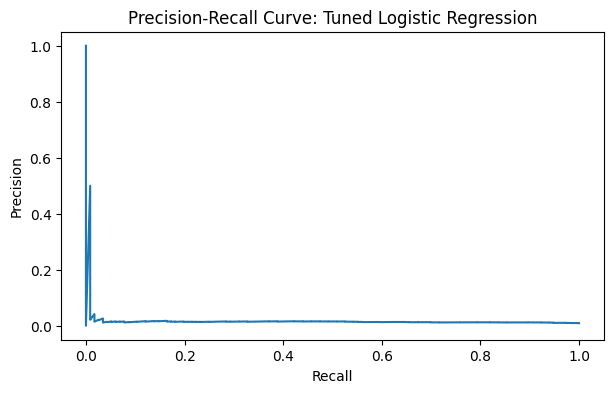

In [74]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_logistic_tuned
)

plt.figure(figsize=(7, 4))

plt.plot(recall, precision)

plt.title("Precision-Recall Curve: Tuned Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

#### Precision-Recall Curve Insight

The precision-recall curve shows that precision remains low across most recall
levels.

Very high precision occurs only when the model identifies an extremely small
number of customers, resulting in recall near zero. As recall increases,
precision quickly falls to approximately 1%–2%.

This confirms that the available features provide limited predictive power for
individual conversion. The model is therefore more appropriate for ranking
customers into broad priority groups than for making definitive conversion
predictions.

## 7.16 Conversion Rate by Predicted-Risk Decile

Customers are ranked by predicted conversion probability and divided into ten
equal-sized groups.

A useful ranking model should place a higher concentration of actual converters
in the highest predicted-risk deciles.

In [75]:
decile_results=pd.DataFrame({
    "predicted_probability":y_prob_logistic_tuned,
    "actual_conversion":y_test.reset_index(drop=True)
})

decile_results["decile"]=pd.qcut(
    decile_results["predicted_probability"],
    q=10,
    labels=False,
    duplicates="drop"
)+1

decile_summary=(
    decile_results.groupby("decile")
    .agg(
         customers=("actual_conversion", "size"),
        conversions=("actual_conversion", "sum"),
        conversion_rate=("actual_conversion", "mean"),
        average_predicted_probability=("predicted_probability", "mean")
    )
    .reset_index()
    .sort_values("decile",ascending=False)
)

decile_summary["conversion_rate"]=(
    decile_summary["conversion_rate"]*100
).round(2)

decile_summary["average_predicted_probability"] = (
    decile_summary["average_predicted_probability"] * 100
).round(2)

decile_summary

,decile,customers,conversions,conversion_rate,average_predicted_probability
9,10,1280,19,1.48,68.19
8,9,1280,19,1.48,60.37
7,8,1280,20,1.56,55.72
6,7,1280,9,0.70,51.80
5,6,1280,14,1.09,48.39
4,5,1279,12,0.94,45.02
3,4,1281,13,1.01,41.60
2,3,1280,4,0.31,37.96
1,2,1280,4,0.31,33.62
0,1,1280,2,0.16,26.87


#### Decile Analysis Insight

The highest-ranked customer deciles had substantially higher actual conversion
rates than the lowest-ranked deciles.

Customers in the top three deciles converted at approximately 1.48% to 1.56%,
while customers in the bottom three deciles converted at only 0.16% to 0.31%.

This indicates that the model provides useful ranking ability, even though its
individual probability estimates are not well calibrated. Because class
weights were used during training, the predicted probabilities should be
treated as relative risk scores rather than literal conversion probabilities.

#### Step 8: Uplift Modeling

Traditional conversion models estimate which customers are likely to convert.

Uplift modeling instead estimates the incremental effect of receiving a campaign.
The goal is to identify customers whose likelihood of conversion increases
because they receive the treatment.

#### 8.1 Prepare Men's E-Mail Treatment and Control Groups

The first uplift analysis compares the Men's E-Mail campaign with the No E-Mail
control group. The Women's E-Mail group is excluded so that treatment assignment
is binary.

In [76]:
mens_uplift_df = df[
    df["segment"].isin(["Mens E-Mail", "No E-Mail"])
].copy()

mens_uplift_df["treatment"] = (
    mens_uplift_df["segment"] == "Mens E-Mail"
).astype(int)

print("Dataset shape:", mens_uplift_df.shape)

print("\nTreatment distribution:")
print(mens_uplift_df["treatment"].value_counts())

print("\nConversion rate by treatment:")
print(
    mens_uplift_df.groupby("treatment")["conversion"].mean()
)

Dataset shape: (42613, 13)

Treatment distribution:
treatment
1    21307
0    21306
Name: count, dtype: int64

Conversion rate by treatment:
treatment
0    0.005726
1    0.012531
Name: conversion, dtype: float64


#### Insight

The uplift dataset contains 42,613 customers split almost equally between the
Men's E-Mail treatment group and the No E-Mail control group.

The observed conversion rate was 1.25% for treated customers and 0.57% for
control customers, confirming a positive overall treatment effect.

Step 8.2: Define uplift features and target

For uplift modeling, we should use only pre-treatment customer characteristics. We don't include:

* segment, because treatment is represented separately
* visit or spend, because they occur after treatment
* history_segment, because it duplicates the information already contained in history

In [77]:
uplift_features = [
    "recency",
    "history",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel"
]

X_uplift = mens_uplift_df[uplift_features]
y_uplift = mens_uplift_df["conversion"]
treatment_uplift = mens_uplift_df["treatment"]

print("Feature shape:", X_uplift.shape)
print("Target shape:", y_uplift.shape)
print("Treatment shape:", treatment_uplift.shape)

Feature shape: (42613, 7)
Target shape: (42613,)
Treatment shape: (42613,)


### Insight

The uplift modeling dataset contains 42,613 customers and seven pre-treatment customer features.

The feature, outcome, and treatment datasets contain the same number of rows, confirming that they are correctly aligned.

Step 8.3: Create uplift training and test sets

We need the same customers’ features, outcomes, and treatment assignments to stay together during the split.

We’ll stratify using both treatment and conversion status so the rare converters are represented across treatment and control in both sets [uplift_strata is only used to make the train-test split more balanced]

In [80]:

#Preserve roughly the same proportion of all four treatment-conversion combinations in both the training and test sets.
uplift_strata = (
    treatment_uplift.astype(str)
    .str.cat(y_uplift.astype(str), sep="_")
)

(
    X_uplift_train,
    X_uplift_test,
    y_uplift_train,
    y_uplift_test,
    treatment_train,
    treatment_test
) = train_test_split(
    X_uplift,
    y_uplift,
    treatment_uplift,
    test_size=0.20,
    random_state=42,
    stratify=uplift_strata
)

print("Training feature shape:", X_uplift_train.shape)
print("Test feature shape:", X_uplift_test.shape)

print("\nTraining treatment distribution:")
print(treatment_train.value_counts())

print("\nTest treatment distribution:")
print(treatment_test.value_counts())

Training feature shape: (34090, 7)
Test feature shape: (8523, 7)

Training treatment distribution:
treatment
0    17045
1    17045
Name: count, dtype: int64

Test treatment distribution:
treatment
1    4262
0    4261
Name: count, dtype: int64


### Finding

The uplift dataset was split into training and test sets while preserving the
treatment-outcome combinations.

The treatment and control groups remain nearly perfectly balanced in both sets,
which supports a fair comparison of predicted outcomes under treatment and
control.

## 8.4 Build the Treatment Conversion Model

The treatment model is trained only on customers who received the Men's E-Mail
campaign.

It estimates each customer's probability of conversion under treatment based
on their pre-campaign characteristics.

In [81]:
#First, select the treated training customers:
treatment_mask_train = treatment_train == 1

X_treatment_train = X_uplift_train.loc[treatment_mask_train]
y_treatment_train = y_uplift_train.loc[treatment_mask_train]

print("Treatment training shape:", X_treatment_train.shape)
print("Treatment conversions:", y_treatment_train.sum())
print("Treatment conversion rate:", y_treatment_train.mean())

Treatment training shape: (17045, 7)
Treatment conversions: 213
Treatment conversion rate: 0.012496333235552949


Insight: Because the positive class is still extremely rare, a full uplift-modeling deep dive could become unstable and overly complicated for this portfolio project. The safest finish is:

Build the treatment model
Build the control model
Score the same test customers under both
Calculate predicted uplift
Rank customers into deciles
Stop there and state the limitations honestly

So next, build both models using logistic regression rather than adding more XGBoost tuning.

In [85]:
uplift_numeric_features = [
    "recency",
    "history"
]

uplift_binary_features = [
    "mens",
    "womens",
    "newbie"
]

uplift_categorical_features = [
    "zip_code",
    "channel"
]

uplift_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            uplift_numeric_features
        ),
        (
            "binary",
            "passthrough",
            uplift_binary_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            uplift_categorical_features
        )
    ]
)

In [86]:
# create two separate pipelines:
uplift_treatment_model = Pipeline(
    steps=[
        ("preprocessor", uplift_preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                penalty="l1",
                C=0.01,
                solver="liblinear",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

uplift_control_model = clone(uplift_treatment_model)

In [ ]:
#Now fit them:

In [87]:
control_mask_train = treatment_train == 0

X_control_train = X_uplift_train.loc[control_mask_train]
y_control_train = y_uplift_train.loc[control_mask_train]

uplift_treatment_model.fit(
    X_treatment_train,
    y_treatment_train
)

uplift_control_model.fit(
    X_control_train,
    y_control_train
)

print("Treatment model trained.")
print("Control model trained.")

Treatment model trained.
Control model trained.


Step 8.5: Calculate Predicted Uplift

For each test customer, we estimate:

probability of conversion under treatment
probability of conversion under control
predicted uplift = treatment probability − control probability

In [88]:
treatment_probability = (
    uplift_treatment_model.predict_proba(X_uplift_test)[:, 1]
)

control_probability = (
    uplift_control_model.predict_proba(X_uplift_test)[:, 1]
)

uplift_results = X_uplift_test.copy()

uplift_results["actual_conversion"] = (
    y_uplift_test.values
)

uplift_results["actual_treatment"] = (
    treatment_test.values
)

uplift_results["treatment_probability"] = (
    treatment_probability
)

uplift_results["control_probability"] = (
    control_probability
)

uplift_results["predicted_uplift"] = (
    uplift_results["treatment_probability"]
    - uplift_results["control_probability"]
)

uplift_results[
    [
        "actual_treatment",
        "actual_conversion",
        "treatment_probability",
        "control_probability",
        "predicted_uplift"
    ]
].head()

#Interpretation:

#positive uplift: customer is predicted to benefit from the email
#near-zero uplift: email is predicted to have little effect
#negative uplift: email may reduce conversion probability

,actual_treatment,actual_conversion,treatment_probability,control_probability,predicted_uplift
51594,1,0,0.428138,0.364476,0.063662
25714,1,0,0.424610,0.308208,0.116402
3017,1,0,0.607204,0.557733,0.049471
36001,0,0,0.408127,0.271857,0.136271
21347,0,0,0.541888,0.563381,-0.021493


### Insight

The two-model approach produced a predicted uplift score for each customer by
subtracting the predicted control outcome from the predicted treatment outcome.

Positive values indicate customers who are expected to benefit from the Men's
E-Mail campaign, while negative values indicate customers for whom the campaign
may have little or potentially negative impact.

Because the underlying models used class weighting, the individual predicted
probabilities should be interpreted as relative scores rather than calibrated
conversion probabilities.

Final step: Uplift deciles

Now rank customers by predicted uplift and compare the observed treatment effect within each decile:

In [89]:
uplift_results["uplift_decile"] = pd.qcut(
    uplift_results["predicted_uplift"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

uplift_decile_summary = (
    uplift_results
    .groupby(["uplift_decile", "actual_treatment"])
    .agg(
        customers=("actual_conversion", "size"),
        conversions=("actual_conversion", "sum"),
        conversion_rate=("actual_conversion", "mean")
    )
    .reset_index()
)

uplift_decile_pivot = uplift_decile_summary.pivot(
    index="uplift_decile",
    columns="actual_treatment",
    values="conversion_rate"
).reset_index()

uplift_decile_pivot.columns = [
    "uplift_decile",
    "control_conversion_rate",
    "treatment_conversion_rate"
]

uplift_decile_pivot["observed_uplift"] = (
    uplift_decile_pivot["treatment_conversion_rate"]
    - uplift_decile_pivot["control_conversion_rate"]
)

uplift_decile_pivot = uplift_decile_pivot.sort_values(
    "uplift_decile",
    ascending=False
)

uplift_decile_pivot[
    [
        "uplift_decile",
        "control_conversion_rate",
        "treatment_conversion_rate",
        "observed_uplift"
    ]
].round(4)

,uplift_decile,control_conversion_rate,treatment_conversion_rate,observed_uplift
9,10,0.0000,0.0022,0.0022
8,9,0.0046,0.0095,0.0049
7,8,0.0048,0.0115,0.0067
6,7,0.0068,0.0121,0.0053
5,6,0.0023,0.0118,0.0094
4,5,0.0024,0.0093,0.0070
3,4,0.0044,0.0101,0.0056
2,3,0.0114,0.0169,0.0054
1,2,0.0096,0.0184,0.0088
0,1,0.0099,0.0246,0.0147


#### Uplift Model Evaluation

The two-model uplift approach did not produce a reliable ranking of customers
by incremental campaign response.

A successful uplift model would be expected to show the highest observed
treatment effect among customers assigned to the highest predicted-uplift
deciles. However, the observed uplift did not increase consistently across the
deciles. In fact, the lowest predicted-uplift decile produced the largest
observed treatment effect.

This indicates that the treatment and control models did not contain enough
predictive signal to estimate reliable customer-level treatment effects.

The likely limitations include the very low conversion rate, the small number
of positive outcomes within each subgroup, limited customer features, and
uncalibrated probabilities produced by class-weighted models.

Therefore, the uplift results should be treated as exploratory and should not
be used to make customer-targeting decisions.

# Final Conclusion

The randomized experiment provided strong evidence that both email campaigns
improved customer outcomes compared with sending no email.

The Men's E-Mail campaign delivered the strongest overall performance. It
increased conversion by approximately 0.68 percentage points, generated about
145 incremental conversions, and produced approximately \$16,403 in estimated
incremental revenue.

The Women's E-Mail campaign also generated a statistically significant positive
effect, but its conversion lift and incremental revenue were smaller.

Customer-segment analysis showed particularly strong campaign response among
Multichannel customers and new customers.

Among the conversion-prediction models, tuned Logistic Regression performed
best, although its predictive strength remained modest because conversions were
rare and the available customer features were limited. The model was more useful
for broad customer ranking than for individual conversion prediction.

The exploratory uplift model did not reliably identify customers with the
largest incremental treatment response. More detailed behavioral data, larger
numbers of converters, and specialized uplift-modeling methods would be needed
before using customer-level uplift scores for targeting.

Overall, the strongest business recommendation is to prioritize the Men's
E-Mail campaign, particularly for Multichannel and new customers, while
continuing to test targeting strategies through randomized experiments.